In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator

### Functions

In [2]:
##--------------------- Distance to the coast -----------------------##
def _islatlon(lat, lon):
    """
    Rough MATLAB-style range check:  -90 ≤ lat ≤ 90  and  -180 ≤ lon ≤ 360
    """
    return (np.all(lat >= -90) and np.all(lat <= 90) and
            np.all(lon >= -180) and np.all(lon <= 360))


def dist2coast(lati, loni, *, matfile="/gxfs_work/geomar/smomw662/NHCS/Master_Thesis/distance2coast.mat"):
    """
    dist2coast  –  Great-circle distance [km] from any point(s) to the nearest coastline.
    
    Parameters
    ----------
    lati, loni : array-like
        Latitudes and longitudes of the target points (same shape, any dimensionality).
    matfile : str, optional
        Path to the `distance2coast.mat` file containing variables
        `lat`, `lon`, and `D` (pre-computed distance grid).

    Returns
    -------
    di : ndarray
        Array of the same shape as `lati`/`loni` with distances in kilometres.
    """
    # Convert inputs to ndarray, preserve original shape for the return
    lati = np.asanyarray(lati, dtype=float)
    loni = np.asanyarray(loni, dtype=float)

    # --- Error checks (MATLAB narginchk / asserts) ------------------------
    if lati.shape != loni.shape:
        raise ValueError("Dimensions of input coordinates must agree.")
    if not _islatlon(lati, loni):
        raise ValueError(
            "Input coordinates appear to be outside the normal latitude/longitude "
            "ranges. Check inputs (and their order) and try again."
        )

    # --- Wrap any 0↠360 longitudes into -180↠180 --------------------------
    loni = np.where(loni > 180, loni - 360, loni)

    # --- Load coastline-distance grid from .mat ---------------------------
    mat = loadmat(matfile)
    lat = mat["lat"].ravel()        # 1-D vectors
    lon = mat["lon"].ravel()
    D   = mat["D"]                  # 2-D matrix, same dims as (lat, lon)

    # --- Wrap the data set itself for seamless Date-Line interpolation ----
    D_wrap  = np.concatenate([D[:, -5:], D, D[:, :5]], axis=1)  # MATLAB: end-4:end, 1:5
    lon_wrap = np.concatenate([lon[-5:] - 360, lon, lon[:5] + 360])

    # --- Linear 2-D interpolation (RegularGridInterpolator) ---------------
    interp = RegularGridInterpolator(
        (lat, lon_wrap),
        D_wrap.astype(float),
        method="linear",
        bounds_error=False,
        fill_value=np.nan,   # mirror MATLAB’s NaN outside the grid
    )

    # Sample the interpolant at the requested points
    pts = np.column_stack((lati.ravel(), loni.ravel()))
    di  = interp(pts).reshape(lati.shape)

    return di #in km

In [3]:
#### Inshore mask
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [4]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [5]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

In [6]:
LON, LAT = np.meshgrid(ds.lon_rho.compute().values[0,:],ds.lat_rho.compute().values[:,0])
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

### Data

In [7]:
#---- Wmld
time = pd.date_range(start="1980-01",end="2016-01",freq='M')

WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
# print(WMLD_data.keys())
#----- Analytical Velocity
AV_data = loadmat("../../NHCS/Processed/AV.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#-------- BEUTI
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")

#-------- BUI 
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")

#--- UIs
WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask*inshore_mask),
        # 'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)*expanded_mask*inshore_mask),
        # 'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)*expanded_mask*inshore_mask),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)*expanded_mask*inshore_mask),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1*expanded_mask*inshore_mask),
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1*expanded_mask*inshore_mask),
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)*expanded_mask*inshore_mask),        

    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

#--- MLD
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask*inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

#--- winds
new_w = loadmat("../../NHCS/Processed/new_winds.mat")

winds_ds = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), new_w['uwind'].transpose(2, 1, 0)),
        'v10':(("time", "lat","lon"), new_w['vwind'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)



/tmp/ipykernel_1013779/4007000054.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


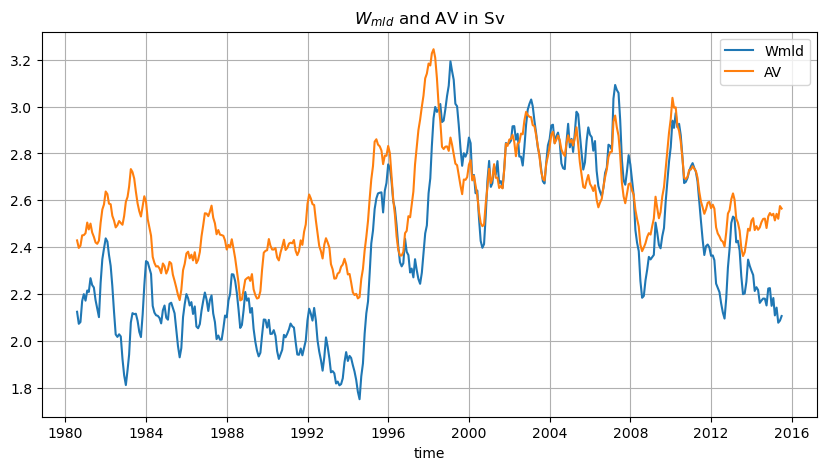

In [8]:
## Sverdrup
A = 6371.0e3

ndelta_y = -(np.deg2rad(WMLD_ds_.lat.shift(lat=-1) - WMLD_ds_.lat) * A)
ndelta_x = (
    np.deg2rad(WMLD_ds_.lon.shift(lon=-1) - WMLD_ds_.lon) * A
    * np.cos(np.deg2rad(WMLD_ds_.lat))
)

da = ndelta_x * ndelta_y

#---- Wmld
Sv_wmld = WMLD_ds_.WMLD * da
Wmld_Sv = -Sv_wmld.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6
Wmld_Sv.rolling(time=13,center=True).mean().plot(figsize=(10,5),label='Wmld')

#---- AV
Sv_AV = WMLD_ds_.AV * da
AV_Sv = -Sv_AV.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6
AV_Sv.rolling(time=13,center=True).mean().plot(label='AV')

plt.grid()
plt.title('$W_{mld}$ and AV in Sv')
plt.legend()

### Ekman Pump and Transport calculation

In [9]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
rho = 1000
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10

delta_y = np.deg2rad(winds_ds.lat.shift(lat=-1) - winds_ds.lat) * A
delta_x = (
    np.deg2rad(winds_ds.lon.shift(lon=-1) - winds_ds.lon) * A
    * np.cos(np.deg2rad(winds_ds.lat))
)

dtauy_by_dx = (tauy.shift(lon=-1) - tauy) / delta_x
dtauy_by_dx = (dtauy_by_dx.shift(lat=-1) + dtauy_by_dx) / 2.0

dtaux_by_dy = (taux.shift(lat=-1) - taux) / delta_y
dtaux_by_dy = (dtaux_by_dy.shift(lon=-1) + dtaux_by_dy) / 2.0

lon1 = (winds_ds.lon.shift(lon=-1) + winds_ds.lon) / 2
lat1 = (winds_ds.lat.shift(lat=-1) + winds_ds.lat) / 2

dtaux_by_dy = dtaux_by_dy.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))
dtauy_by_dx = dtauy_by_dx.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))

curlz_tau = (dtauy_by_dx - dtaux_by_dy)

#new f
f = 2 * 7.2921e-5 * np.sin(np.deg2rad(curlz_tau.lat))
w_ek = (1/f/rho) * curlz_tau
w_ek = w_ek.transpose('time','lat','lon')

ndelta_y = (np.deg2rad(w_ek.lat.shift(lat=-1) - w_ek.lat) * A)
ndelta_x = (
    np.deg2rad(w_ek.lon.shift(lon=-1) - w_ek.lon) * A
    * np.cos(np.deg2rad(w_ek.lat))
)


dd = ndelta_x * ndelta_y
dd

#--- Ekman pump
total_wek = w_ek * inshore_mask[:-1,:-1] * dd
sv_wek = total_wek.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6

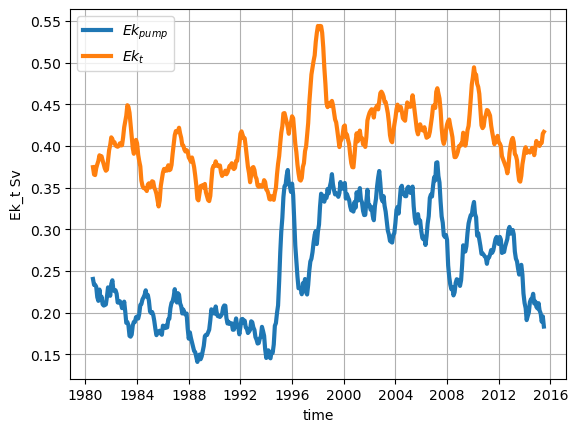

In [10]:
f = 2 * omega * np.sin(np.radians(winds_ds.lat))

U_ekman = tauy / (rho * f)

ek_t_sv = (-U_ekman * inshore_mask * delta_y).sel(lat=slice(-16,-5)).sum(dim='lat')/ 1e6

sv_wek.rolling(time=13,center=True).mean().plot(label="$Ek_{pump}$",linewidth=3)
ek_t_sv.where(ek_t_sv).mean(dim='lon').rename("Ek_t Sv").rolling(time=13,center=True).mean().plot(label="$Ek_t$",linewidth=3)
plt.grid()
plt.legend()

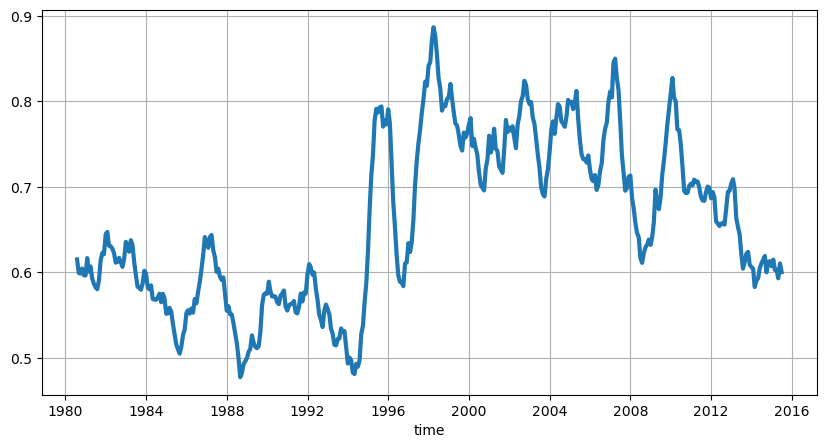

In [11]:
TWDU = (ek_t_sv.where(ek_t_sv).mean(dim='lon').rename("Ek_t Sv") + sv_wek.rename('SV')).rolling(time=13,center=True).mean()
TWDU.plot(
    figsize=(10,5),label='$Ek_{pump}$',linewidth=3)
plt.grid()

In [12]:
f = 2 * omega * np.sin(np.radians(WMLD_ds_.lat))

U_ekman = tauy / (rho * f)

CUTI_sv = (WMLD_ds_.CUTI * inshore_mask * delta_y).sel(lat=slice(-16,-5)).sum(dim='lat')/ 1e6
BUI_sv = (-U_ekman * inshore_mask * delta_y * np.cos(-112.27)).sel(lat=slice(-16,-5)).sum(dim='lat')/ 1e6

# BUI_sv = (WMLD_ds_.BUI * inshore_mask * delta_y).sel(lat=slice(-16,-5)).sum(dim='lon')/ 1e6
BEUTI_sv = (WMLD_ds_.BEUTI * inshore_mask * delta_y).sel(lat=slice(-16,-5)).sum(dim='lat')/ 1e6


In [13]:
np.cos(-112.27)

0.6768395587049194

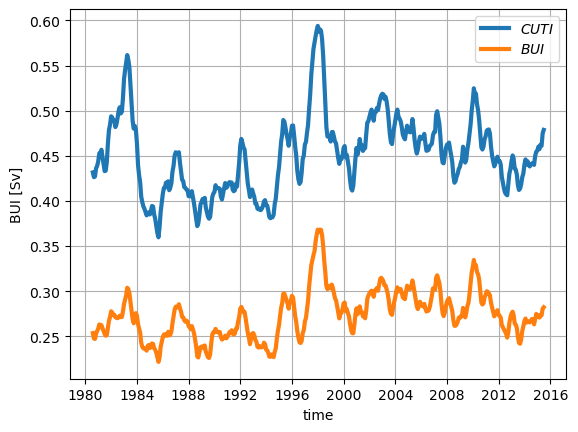

In [14]:
CUTI_sv.where(CUTI_sv).mean(dim='lon').rename("CUTI [Sv]").rolling(time=13,center=True).mean().plot(label="$CUTI$",linewidth=3)
BUI_sv.where(BUI_sv).mean(dim='lon').rename("BUI [Sv]").rolling(time=13,center=True).mean().plot(label="$BUI$",linewidth=3)

plt.grid()
plt.legend()

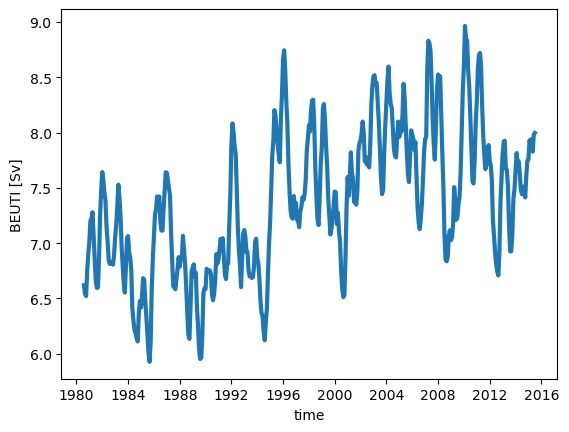

In [15]:
BEUTI_sv.where(BEUTI_sv).mean(dim='lon').rename("BEUTI [Sv]").rolling(time=13,center=True).mean().plot(label="$BEUTI$",linewidth=3)

In [16]:
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

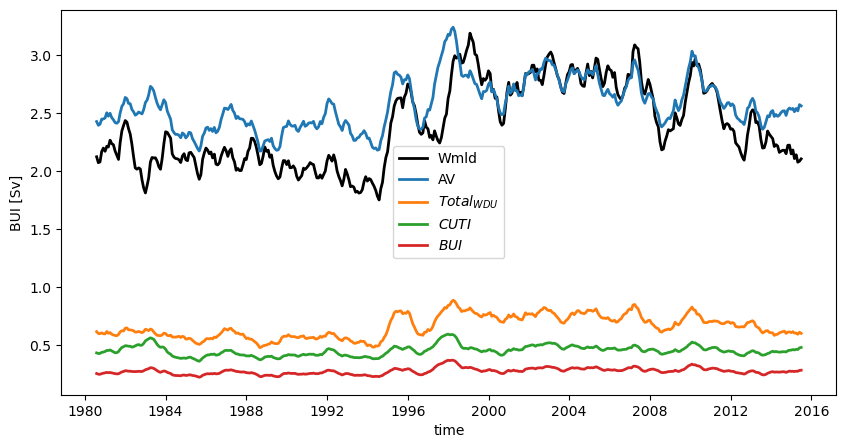

In [17]:
Wmld_Sv.rolling(time=13,center=True).mean().plot(label='Wmld',linewidth=2,color='black',figsize=(10,5))
AV_Sv.rolling(time=13,center=True).mean().plot(label='AV',linewidth=2)
TWDU.plot(label='$Total_{WDU}$',linewidth=2)
CUTI_sv.where(CUTI_sv).mean(dim='lon').rename("CUTI [Sv]").rolling(time=13,center=True).mean().plot(label="$CUTI$",linewidth=2)
BUI_sv.where(BUI_sv).mean(dim='lon').rename("BUI [Sv]").rolling(time=13,center=True).mean().plot(label="$BUI$",linewidth=2)

plt.legend()

### Plots

Text(0.5, 1.0, 'Transport in Sv')

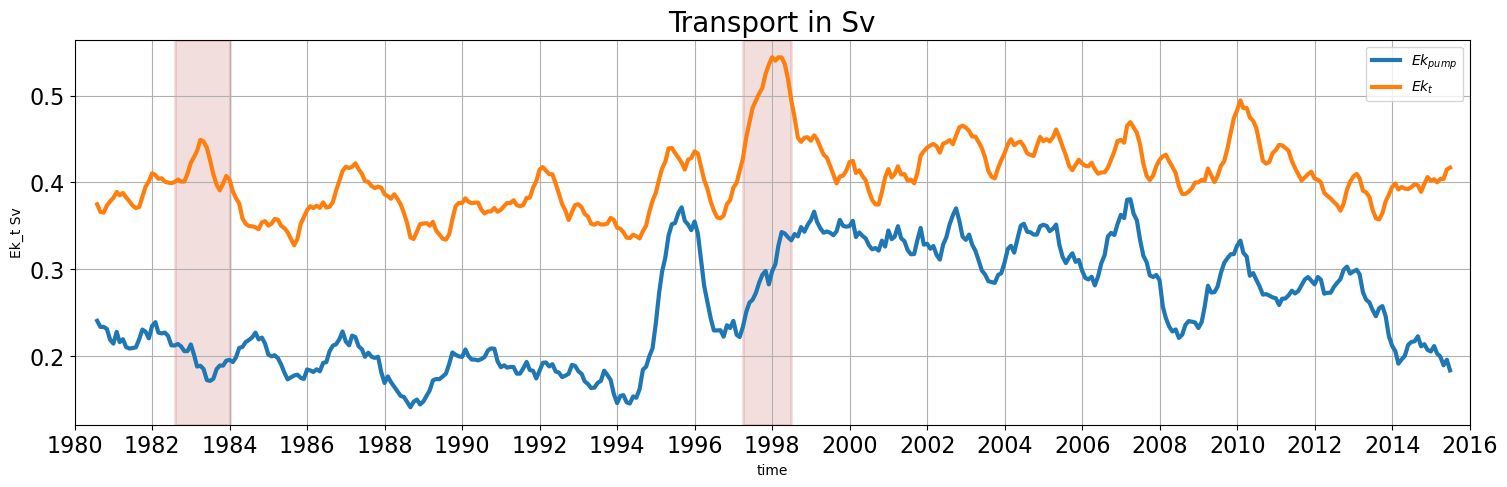

In [18]:
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle

sv_wek.rename('SV').rolling(time=13,center=True).mean().plot(
    figsize=(18,5),label='$Ek_{pump}$',linewidth=3)
# ek_t_sv.rename("Ek_t Sv").sel(lat=slice(-16,-5)).mean(dim=('lat')).rolling(time=13,center=True).mean().plot(
#     label="$Ek_t$",linewidth=3)

ek_t_sv.where(ek_t_sv).mean(dim='lon').rename("Ek_t Sv").rolling(time=13,center=True).mean().plot(label="$Ek_t$",linewidth=3)

plt.grid()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')
plt.legend()
plt.title('Transport in Sv',fontsize=20)

Text(0.5, 1.0, 'Transport in Sv Wmld and AV')

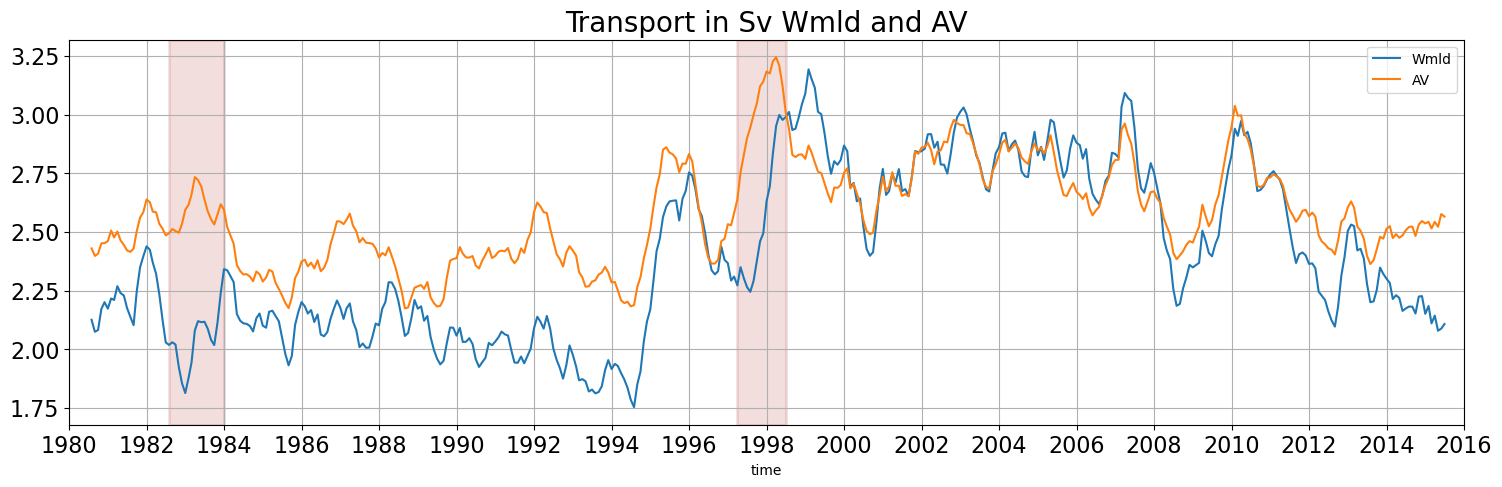

In [19]:
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle

Wmld_Sv.rolling(time=13,center=True).mean().plot(figsize=(18,5),
                                                 label='Wmld')

AV_Sv.rolling(time=13,center=True).mean().plot(label='AV')

plt.grid()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')
plt.legend()
plt.title('Transport in Sv Wmld and AV',fontsize=20)

### Seasonality

In [21]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

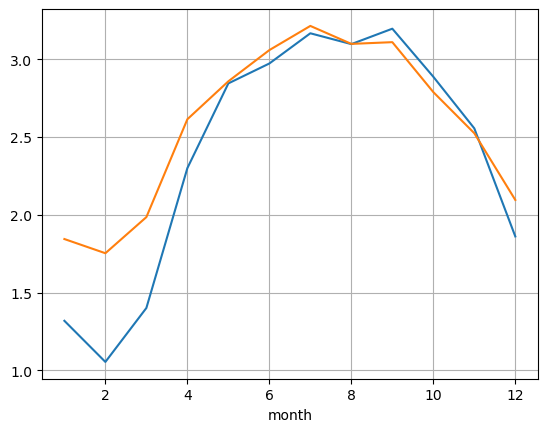

In [26]:
seasonality(Wmld_Sv).plot()
seasonality(AV_Sv).plot()
plt.grid()

In [27]:
seasonality(Wmld_Sv)

<xarray.DataArray (month: 12)> Size: 96B
array([1.31900881, 1.05475638, 1.40137165, 2.30003401, 2.84458132,
       2.97249128, 3.16659473, 3.09701705, 3.19608644, 2.88725057,
       2.55559144, 1.86117515])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [28]:
np.mean([2.97249128, 3.16659473, 3.09701705])

3.07870102